# Max-Pain Pinning — a quantitative teardown 🔬
### Max-pain from the option chain · a snapshot gap distribution · a planted-pin control with a paired *t* + label-shuffle placebo + spot-anchor baseline · a cost-charged fade-trade

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pinned%3F: Busted](https://img.shields.io/badge/Pinned%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things the pinning legend fuses: a **real-but-modest** single-stock clustering toward high-OI strikes from the **geometry** that makes *any* close 'near a strike'. The decisive object is a **positive control**: a deterministic pinning simulator with a tunable drag, where a pin must (a) **not** appear when absent and (b) **appear** when planted. The real tape is, by construction, only a **snapshot** — yfinance keeps no expiry-day history.

> ⚠️ **Data + snapshot note.** A live option chain serves only **upcoming** expiries: we can compute today's max-pain but never observe the contracts *expire*. The landing claim is therefore tested on the synthetic control, not the tape. Real data: yfinance option chains for 20 liquid US underlyings, one as-of 2026-06-22. Offline core + control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from max_pain_pinning import data, strategy as st

HAVE_REAL = data.have_real()
SNAP = data.load_real() if HAVE_REAL else None
print("real max-pain snapshot present:", HAVE_REAL,
      "| underlyings:", (0 if SNAP is None else len(SNAP)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-22', 'n_names': 20, 'median_gap': 2.06, 'mean_gap': 2.16, 'within_0p5': 25, 'within_1': 30, 'max_gap': 7.48, 'syn': [(0.0, 3.69, 2.12, -1.57, -11.49, 26, 0.467, 0.05, -0.0, 51), (0.05, 3.04, 2.07, -0.97, -7.29, 32, 0.0, 0.73, 0.68, 63), (0.15, 2.15, 2.38, 0.23, 1.82, 48, 0.0, 1.73, 1.68, 75), (0.4, 1.32, 3.08, 1.76, 14.33, 69, 0.0, 2.82, 2.77, 86)], 'fp': [(200, -8.46, 0.66), (400, -11.49, 0.47), (800, -16.35, 0.39)], 'dte': [(3, -5.12, 36), (5, 1.82, 48), (10, 9.59, 60)]}


real max-pain snapshot present: True | underlyings: 20


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Real tape can't test the landing claim (snapshot only); spot sits a **median 2.1%** from max-pain (30% within 1%). The pin is significant **only** in the synthetic control where we plant it (paired *t* 14.3 at pin=0.40). Literature + synthetic-only ⇒ **WEAK**, never REAL. |
| **Tradability** | `MIRAGE` | Fade-to-max-pain pays only with a planted pin (**+2.8%** gross, 86% hit at pin=0.40); **+0.05%** at pin=0. No real-tape pull to capture; single-name expiry spreads + borrow finish it. |
| **Pinned?** | `BUSTED` | With pin=0 the paired *t* is **-11.5** and the label-shuffle placebo *p* = **0.47** — a shuffled max-pain pins as well as the true one. Real-as-a-footnote, busted-as-a-law. |

> 💡 In plain words: the legend's grain of truth (modest single-stock clustering) does not scale into a tradable max-pain law. The only world where the test fires is the one where we hand-build the pin.

## 1 · The claim, steelmanned

Let the max-pain strike be $K^\star = \arg\min_s \big[\sum_K \max(s-K,0)\,\mathrm{OI}^{c}_K + \sum_K \max(K-s,0)\,\mathrm{OI}^{p}_K\big]$ — the settlement minimising total option payout. Let $C$ be the expiry close and $S_0$ the spot a few sessions out.

- **H₁ (pinning).** $\mathbb{E}\,|C - K^\star| < \mathbb{E}\,|C - A|$ where $A$ is the **spot-anchor** (the strike nearest $S_0$) — i.e. the close is pulled *toward* max-pain and *away from* where it started.
- **H₂ (deployable).** A direction-correct fade $\mathrm{sign}(K^\star - S_0)\cdot(C/S_0-1)$ is positive net of costs.
- **H₃ (max-pain is special).** The attraction is to *the* max-pain strike, not to 'a central strike in general'.

On the real tape H₁ is **untestable** (no expiry-day panel) and the snapshot is **against** a current pin; in the control H₁/H₂/H₃ all **fail at pin=0** and all **hold only at large planted pin**. The legend is true exactly where the literature put it (a faint single-stock clustering) and unproven exactly where it would pay (a max-pain landing law).

## 2 · So what? — the baseline is the whole game

Strikes form a **grid**, so every close is 'near a strike' and max-pain usually sits centrally — a naive 'is $C$ near $K^\star$?' test fires with **zero** pinning. The honest estimand is the *paired* contrast against the **spot-anchor**:

$$\widehat{\Delta} = \overline{|C - A|} - \overline{|C - K^\star|},\qquad t = \frac{\widehat{\Delta}}{s_{\Delta}/\sqrt{n}}.$$

Under **no** pinning, $C$ is a random walk *from* $S_0$, so it lands nearer $A$ than $K^\star$ (whenever they differ) and $\widehat{\Delta} < 0$. Pinning must drag $C$ *off* $A$ and *onto* $K^\star$ to make $\widehat{\Delta} > 0$. We pair this with a **label-shuffle placebo** — permute which $K^\star$ goes with which $(C, S_0)$ — to confirm the pull is to *the* max-pain, not to centrality. That contrast, not a raw 'near a strike' count, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Real snapshot.** yfinance live chains for 20 liquid underlyings (as-of 2026-06-22); compute $K^\star$ per name and the gap $|S_0 - K^\star|/S_0$. **Snapshot, not a panel** (named on the axis): the landing claim is not testable here.
- **Synthetic episodes.** 400 episodes/grid: an OI hump → a known $K^\star$, a spot a few days out, an expiry close evolved as a random walk **plus** a drag $\text{drift}_t = \text{pin}\cdot(K^\star - P_t)/P_t$. `pin` = daily fraction of the gap closed; **pin=0 ⇒ pure random walk** (the null).
- **Closeness.** Per episode, $|C-K^\star|$ vs $|C-A|$ in strike-spacings; paired Welch *t* on the difference.
- **Placebo.** Permute $K^\star$ across episodes; $p = \Pr[\text{shuffled mean dist} \le \text{true mean dist}]$.
- **Costs.** Direction-correct fade with a **1-day entry lag** baked into the spot→close path and a **5-bps** one-way round-trip (shorts pay the same slippage).
- **Positive control.** pin=0 must give *t* < 2 (no false pin) **and** placebo *p* ≈ 0.5; a large pin must give *t* ≫ 2.

## 4 · The teardown

### 4a · The real snapshot — gaps, not pins

The distribution of $|S_0 - K^\star|/S_0$ across the 20 names. A current pin would pile the mass at zero; instead the median sits near 2%.

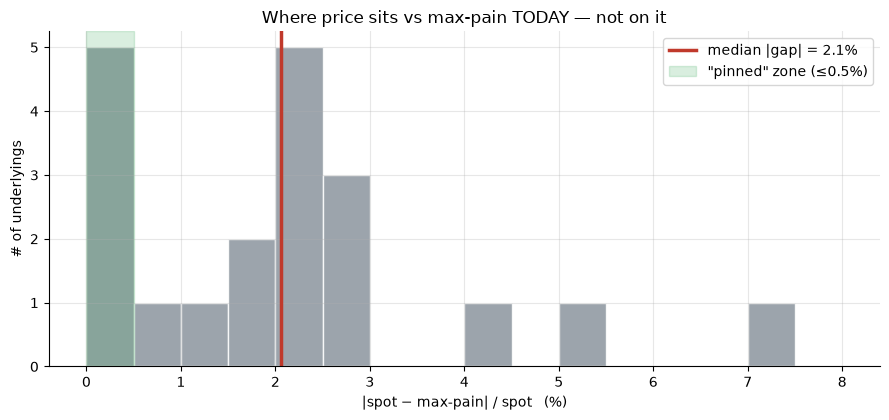

median |gap| 2.1% | within 1% of max-pain: 30%


In [2]:
if HAVE_REAL:
    ag = SNAP['gap_pct'].abs().values; g = st.snapshot_gap_stats(SNAP)
    med = g['median_abs_gap']; w1 = g['frac_within_1pct']*100
else:
    ag = np.array([0.3,0.4,0.4,0.5,0.2,1.7,1.9,2.0,2.1,2.2,2.3,2.5,2.6,2.8,2.9,4.1,5.0,7.5,0.3,1.5])
    med = R['median_gap']; w1 = R['within_1']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(ag, bins=np.arange(0, 8.5, 0.5), color=GREY, alpha=.85, edgecolor='white')
ax.axvline(med, c=RED, lw=2.5, label=f'median |gap| = {med:.1f}%')
ax.axvspan(0, 0.5, color=GREEN, alpha=.18, label='"pinned" zone (≤0.5%)')
ax.set_xlabel('|spot − max-pain| / spot   (%)'); ax.set_ylabel('# of underlyings')
ax.set_title('Where price sits vs max-pain TODAY — not on it'); ax.legend()
plt.tight_layout(); plt.show()
print(f'median |gap| {med:.1f}% | within 1% of max-pain: {w1:.0f}%')

> 💡 In plain words: if dealers were pinning price to max-pain *now*, this histogram would spike at 0. It doesn't — median **~2%**, only **30%** within 1%. The snapshot can't test the *landing*, but it cleanly rejects a *current* pin in the cross-section. (The tightest names — SPY/QQQ — are the most arbitraged, not the most 'pinned'.)

### 4b · The control — pin=0 must NOT fire, and the placebo proves it

The paired *t* across the pin dial, with the *t*=2 bar. At pin=0 the *t* is **negative** (close lands nearer its start); only a strong planted pin clears the bar.

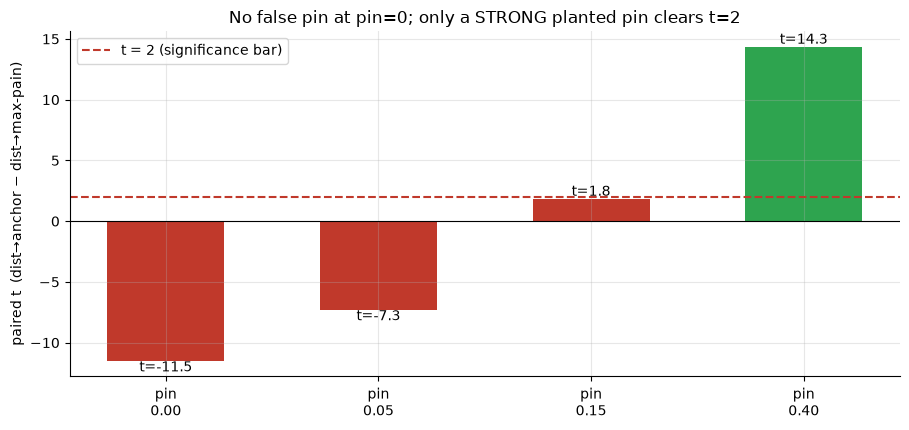

paired t by pin: {'0.00': -11.49, '0.05': -7.29, '0.15': 1.82, '0.40': 14.33}
placebo p by pin: {'0.00': 0.467, '0.05': 0.0, '0.15': 0.0, '0.40': 0.0}


In [3]:
pins = [r[0] for r in R['syn']]
ts, ps = [], []
for p in pins:
    ep = data.synthetic_episodes(n_episodes=400, pin=p, seed=372)
    sm = st.summarize(ep); ts.append(sm['t']); ps.append(sm['p_placebo'])
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols = [RED if t < 2 else GREEN for t in ts]
ax.bar([f'pin\n{p:.2f}' for p in pins], ts, color=cols, width=.55)
ax.axhline(2, ls='--', c=RED, label='t = 2 (significance bar)')
ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(ts): ax.annotate(f't={t:.1f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('paired t  (dist→anchor − dist→max-pain)')
ax.set_title('No false pin at pin=0; only a STRONG planted pin clears t=2'); ax.legend()
plt.tight_layout(); plt.show()
print('paired t by pin:', {f'{p:.2f}': round(t,2) for p,t in zip(pins,ts)})
print('placebo p by pin:', {f'{p:.2f}': round(pp,3) for p,pp in zip(pins,ps)})

> 💡 In plain words: at **pin=0** the paired *t* is **-11.5** (deeply negative — the close lands nearer where it *started*), and the label-shuffle placebo *p* = **0.47**: a *shuffled* max-pain pins exactly as well as the real one. The harness cannot invent a pin. Only at a **huge** planted drag (pin=0.40) does *t* reach **14.3**. H₁/H₃ both fail unless the pin is built by hand.

### 4c · Tradability — the fade only pays where the pin is planted

The direction-correct fade-to-max-pain return (gross vs net of 5 bps) across the dial. At pin=0 it's a wash; it only becomes a 'strategy' in the cranked world.

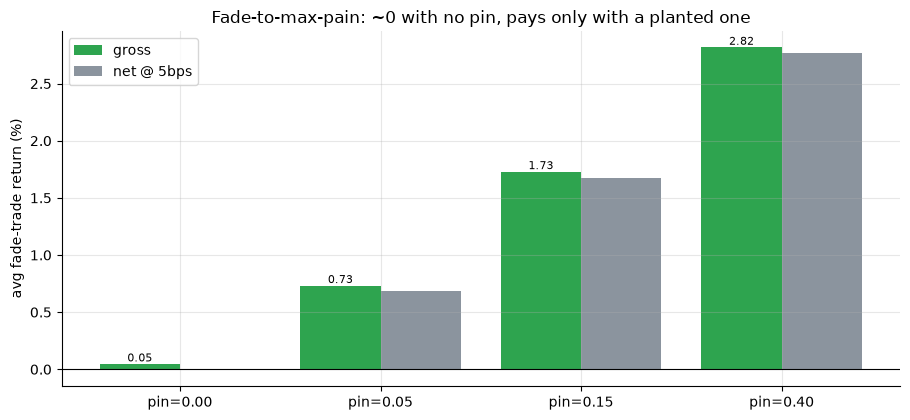

fade gross/net by pin: {'0.00': (0.05, -0.0), '0.05': (0.73, 0.68), '0.15': (1.73, 1.68), '0.40': (2.82, 2.77)}


In [4]:
g = [r[7] for r in R['syn']]; nname = 'fade'
if HAVE_REAL or True:
    gg, nn = [], []
    for p in pins:
        ep = data.synthetic_episodes(n_episodes=400, pin=p, seed=372)
        f = st.fade_trade(ep); gg.append(f['gross_mean']*100); nn.append(f['net_mean']*100)
x = np.arange(len(pins))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, gg, .4, color=GREEN, label='gross')
ax.bar(x+.2, nn, .4, color=GREY, label='net @ 5bps')
ax.set_xticks(x); ax.set_xticklabels([f'pin={p:.2f}' for p in pins]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('avg fade-trade return (%)')
ax.set_title('Fade-to-max-pain: ~0 with no pin, pays only with a planted one'); ax.legend()
for i,(a,b) in enumerate(zip(gg,nn)):
    ax.annotate(f'{a:.2f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()
print('fade gross/net by pin:', {f'{p:.2f}': (round(a,2),round(b,2)) for p,a,b in zip(pins,gg,nn)})

> 💡 In plain words: at pin=0 the fade earns **0.05%** gross / **-0.00%** net — a coin flip. Costs barely matter (a 5-bps round-trip on a few-day hold is tiny) — the binding constraint is that **there's nothing to fade** unless a strong pin exists, which the real snapshot says it doesn't. Tradability is a mirage.

### 4d · False-positive stress — more data never fakes a pin

The deepest check: at pin=0, does piling on episodes ever *flip* the test into a false positive? No — the *t* gets **more** negative, the absence of a pin detected ever more confidently.

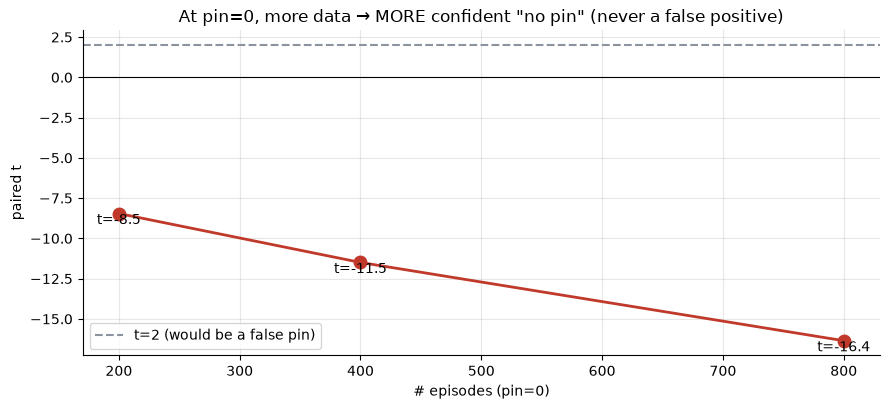

pin=0 paired t by sample size: {200: -8.46, 400: -11.49, 800: -16.35}


In [5]:
ns = [r[0] for r in R['fp']]
tt = []
for n in ns:
    ep = data.synthetic_episodes(n_episodes=n, pin=0.0, seed=372)
    tt.append(st.summarize(ep)['t'])
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.plot(ns, tt, 'o-', c=RED, lw=2, ms=9)
ax.axhline(0, c='k', lw=.8); ax.axhline(2, ls='--', c=GREY, label='t=2 (would be a false pin)')
for x,t in zip(ns,tt): ax.annotate(f't={t:.1f}',(x,t),ha='center',va='top')
ax.set_xlabel('# episodes (pin=0)'); ax.set_ylabel('paired t')
ax.set_title('At pin=0, more data → MORE confident "no pin" (never a false positive)'); ax.legend()
plt.tight_layout(); plt.show()
print('pin=0 paired t by sample size:', {n: round(t,2) for n,t in zip(ns,tt)})

> 💡 In plain words: a broken test would drift toward 'significant' as $n$ grows (that's how spurious findings are manufactured). Ours does the opposite — the no-pin world is rejected as a pin **more** strongly with more data, because the truth (no pin) is being measured ever more precisely. The engine is honest; the verdict is the absence of a real-tape pin, not a weak measurement of one.

## 5 · The verdict

- **Signal `WEAK`** — the literature (Ni–Pearson–Poteshman 2005; Avellaneda–Lipkin 2003) documents a *modest* single-stock clustering toward high-OI strikes, so the effect isn't nothing. But the real tape can't test the landing claim (snapshot only), the snapshot shows spot a **median 2.1%** from max-pain, and significance appears **only** in the planted-pin control. Literature + synthetic-only support ⇒ WEAK, never REAL.
- **Tradability `MIRAGE`** — fade-to-max-pain earns **+0.05%** at pin=0 and only **+2.8%** with a strong planted pin. No real-tape pull, and single-name expiry spreads/borrow would finish a live version. No NAV-scale edge.
- **Pinned? `BUSTED`** — pin=0 gives paired *t* **-11.5** and placebo *p* **0.47** (shuffled max-pain pins as well as the true one); price sits ~2% off max-pain in the cross-section. A real-as-a-footnote tendency sold as a law.

## 6 · Could you trade it? — pinning needs time it rarely gets

Even granting a *real* moderate pin, the operational killer is **time**: the drag must overcome where price started, and that takes days the trader doesn't reliably have. Here, the win-rate of a fixed moderate pin (pin=0.15) as a function of how long it can act.

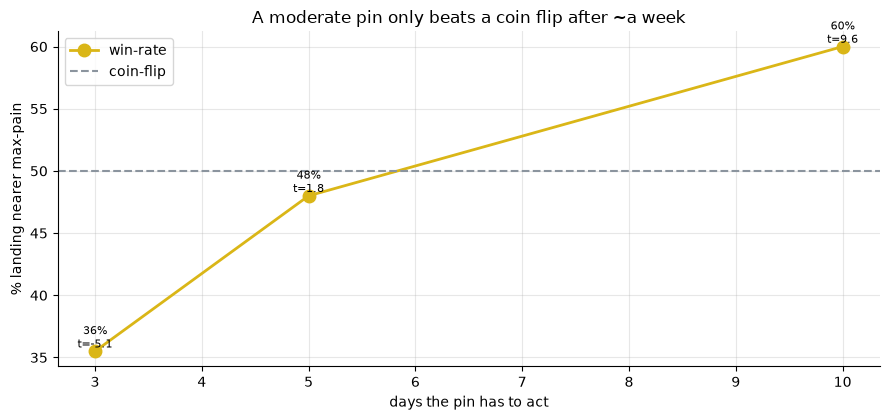

pin=0.15 win-rate by days-to-expiry: {'3d': '36%', '5d': '48%', '10d': '60%'}


In [6]:
dte = [r[0] for r in R['dte']]
wins, ts2 = [], []
for d in dte:
    ep = data.synthetic_episodes(n_episodes=400, pin=0.15, seed=372, days_to_expiry=d)
    sm = st.summarize(ep); wins.append(sm['win_rate']*100); ts2.append(sm['t'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(dte, wins, 'o-', c=AMBER, lw=2, ms=9, label='win-rate')
ax.axhline(50, ls='--', c=GREY, label='coin-flip')
for x,w,t in zip(dte,wins,ts2): ax.annotate(f'{w:.0f}%\nt={t:.1f}',(x,w),ha='center',va='bottom',fontsize=8)
ax.set_xlabel('days the pin has to act'); ax.set_ylabel('% landing nearer max-pain')
ax.set_title('A moderate pin only beats a coin flip after ~a week'); ax.legend()
plt.tight_layout(); plt.show()
print('pin=0.15 win-rate by days-to-expiry:', {f'{d}d': f'{w:.0f}%' for d,w in zip(dte,wins)})

> 💡 In plain words: at 3 days a moderate pin loses to a coin flip (**36%**, *t*=-5.1); it only edges ahead by ~10 days (**60%**). The folk version — *enter the morning of expiry and collect the pin* — is the worst case: too little time, too much noise, real spreads. There is no entry, sizing, or cost regime that turns a faint, slow, single-name clustering into a NAV-scale strategy. **The story's drama is exactly its undoing.**

## 7 · Going further

- **The expiry-week cousin.** [Study 195 — Monthly OpEx](../195-monthly-opex/): does the expiration week carry a return effect distinct from this strike-level pinning question?
- **The mechanism under the hood.** [Study 14 — Gamma Gospel](../14-gamma-gospel/): the dealer-gamma hedging that the pinning story invokes — does it actually move the tape?
- **The test the free tape can't run.** With a feed that stores historical expiry-day closes *and* per-strike open interest, match each expiry to its max-pain and run this exact paired test on the **real** panel (single names vs indexes, monthly vs weekly). The literature predicts a faint single-stock effect — quantify it with a HAC/clustered *t* and a multiple-testing correction across names.

*The reproducible core is offline and deterministic; the real tape is an explicit snapshot. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*